In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from train import train_model

In [2]:
df = pd.read_csv("../data/processed/features.csv")

## Data Exploration

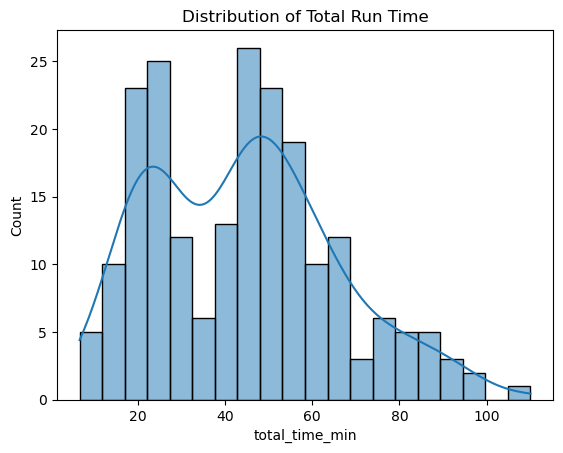

In [3]:
sns.histplot(df['total_time_min'], bins=20, kde=True)
plt.title("Distribution of Total Run Time")
plt.show()

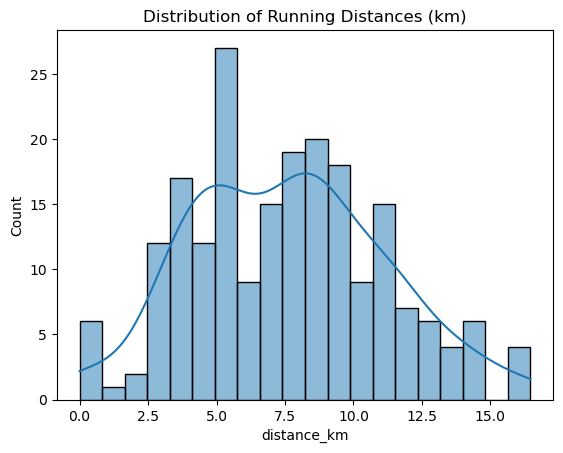

In [4]:
sns.histplot(df['distance_km'], bins=20, kde=True)
plt.title("Distribution of Running Distances (km)")
plt.show()

In [5]:
features = [
    "distance_km",
    "avg_hr",
    "avg_cadence",
    "elevation_per_km",
    "weekly_km",
    "rolling_pace",
    "hr_percent_max",
    "effort_pace"
]
corr = df[features + ["total_time_min"]].corr()
print(corr["total_time_min"].sort_values(ascending=False))

total_time_min      1.000000
distance_km         0.774569
weekly_km           0.248474
effort_pace         0.168172
rolling_pace        0.001134
avg_cadence        -0.073001
hr_percent_max     -0.076397
avg_hr             -0.124286
elevation_per_km   -0.176625
Name: total_time_min, dtype: float64


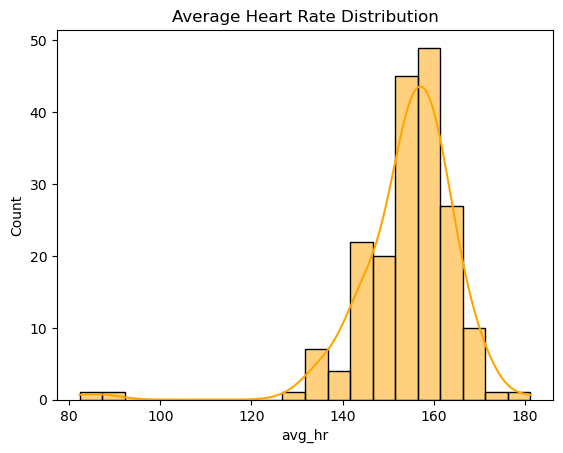

In [6]:
sns.histplot(df['avg_hr'], bins=20, kde=True, color='orange')
plt.title("Average Heart Rate Distribution")
plt.show()

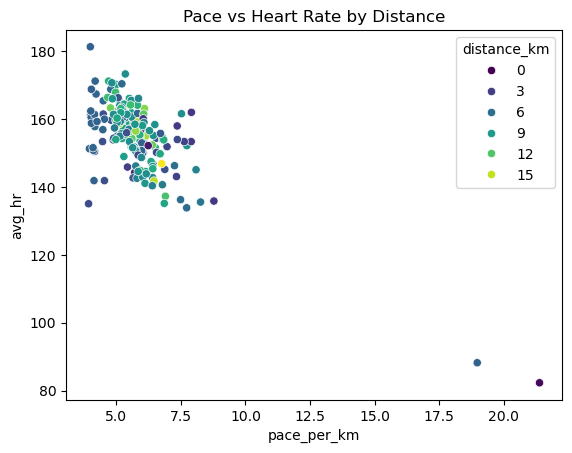

In [7]:
sns.scatterplot(x='pace_per_km', y='avg_hr', data=df, hue='distance_km', palette='viridis')
plt.title("Pace vs Heart Rate by Distance")
plt.show()


## Model Prediction

In [ ]:
output = train_model()

results = output["results"]
y_val = output["y_val"]
preds = output["X_val"]
features = output["feature_importance"]
best_model = output["best_model"]

{'results':                Model       RMSE        R2
0  Linear Regression   3.876957  0.963109
1              Ridge   5.286053  0.931419
3  Gradient Boosting  13.796359  0.532834
2      Random Forest  14.263690  0.500649, 'best_model': 'Linear Regression', 'feature_importance': None, 'X_val':      distance_km  avg_hr  avg_cadence  elevation_per_km  weekly_km  \
108       8.3231   156.5         85.8          4.926049    44.6525   
193       8.0740   161.3         88.8          3.344067    51.1959   
163      11.3679   166.3         86.2          1.829713    47.6281   
137       5.0387   181.2         86.8          0.000000    46.6830   
126       5.1184    88.2         56.6          2.227259    53.6253   
178      11.4885   151.4         87.9          2.933368    61.2746   
162       5.0398   150.7         87.1         11.468709    44.8388   
207       6.7094   157.3         88.8          3.547262    57.0934   
196       7.6470   166.0         85.6          0.000000    52.4174   
144  

In [17]:
def plot_predictions(y_true, y_pred, model_name):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name}: Actual vs Predicted")
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.show()


In [18]:
best_model_name = output["results"].iloc[0]["Model"]
best_model = output["models"][best_model_name]

preds = best_model.predict(output["X_val"])
plot_predictions(output["y_val"], preds, best_model_name)

KeyError: 'models'

ValueError: `dataset` input should have multiple elements.

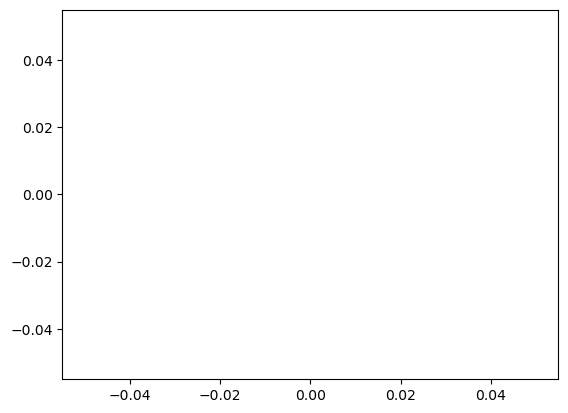

In [14]:
residuals = y_val - preds
sns.histplot(residuals, bins=20, kde=True)
plt.xlabel("Residual (min)")
plt.title("Residual Distribution")
plt.show()


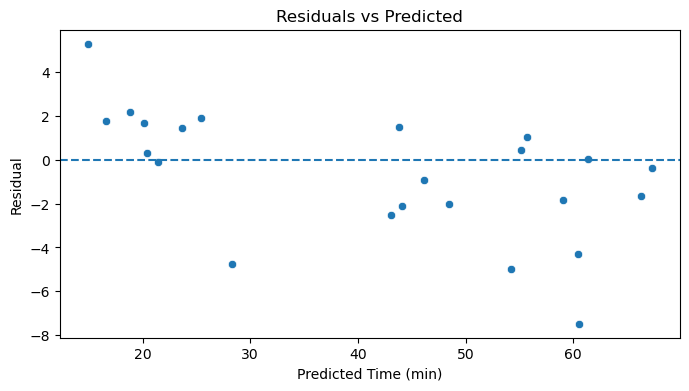

In [9]:
plt.figure(figsize=(8,4))
sns.scatterplot(x=preds, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Time (min)")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()
